# Chương 2 — Matched MLP: NumPy scratch, Keras và PyTorch

Notebook này là lớp kiểm tra và trình bày artifact. Huấn luyện được thực hiện bởi `term_paper.src.common.run_ch2_experiments` trong môi trường có đồng thời Keras và PyTorch. Mọi bảng dưới đây được đọc từ prediction/metric artifact, không nhập số thủ công.

## 1. Protocol khóa

- Split 64/16/20, seed split 42; TEST không dùng để chọn learning rate hoặc threshold.
- Topology: input → Dense(64)+ReLU → Dense(32)+ReLU → output.
- Adam, batch size 512, learning-rate candidates 0.01 và 0.003, early stopping.
- Seed mô hình: 42, 52, 62 vì full run seed 42 dưới ngưỡng 20 phút.
- Binary threshold được chọn bằng F1 trên VALIDATION. Housing train trên standardized log1p target và báo metric sau inverse-transform.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'term_paper').exists())
METRICS = ROOT / 'term_paper' / 'artifacts' / 'metrics'
FIGURES = ROOT / 'term_paper' / 'artifacts' / 'figures' / 'ch2'
print('Workspace:', ROOT)

Workspace: C:\DATA\assign


In [2]:
dataset_summary = pd.read_csv(METRICS / 'ch2_dataset_summary.csv')
framework_runs = pd.read_csv(METRICS / 'ch2_framework_comparison.csv')
framework_summary = pd.read_csv(METRICS / 'ch2_framework_summary.csv')
classical = pd.read_csv(METRICS / 'ch2_classical_baselines.csv')
best_vs_classical = pd.read_csv(METRICS / 'ch2_best_vs_classical.csv')

assert len(framework_runs) == 27
assert set(framework_runs['seed']) == {42, 52, 62}
assert framework_runs.groupby(['dataset_id', 'framework'])['split_sha256'].nunique().max() == 1
assert framework_runs.groupby(['dataset_id', 'framework'])['processed_sha256'].nunique().max() == 1
display(dataset_summary)

,dataset_id,task,raw_rows,model_rows,raw_feature_count,transformed_feature_count,train_rows,val_rows,test_rows,split_sha256,class_0,class_1,positive_rate,target_min,target_median,target_mean,target_max
0,ch2_diabetes_binary,binary,70692,69057,21,21,44196,11049,13812,138c04fa519a96441560b250bf1fbdef2c6041439f654f...,33960.0,35097.0,0.508232,NaN,NaN,NaN,NaN
1,ch2_vietnam_housing,regression,30229,30223,12,143,19342,4836,6045,8d8d69071704b7821d93facb431682530766f2dad2cb12...,NaN,NaN,NaN,1.0,5.9,5.872565,11.5
2,ch2_ecommerce_behavior,binary,10000,10000,51,368,6400,1600,2000,b9bf6fd92b31a05002e1538ad5a930c93e7a0373f58f09...,8306.0,1694.0,0.169400,NaN,NaN,NaN,NaN


## 2. Kết quả matched comparison

F1 là metric chính cho hai bài toán classification; RMSE theo tỷ VND là metric chính cho housing regression. Mean và sample standard deviation được tính trên ba seed.

In [3]:
classification_cols = ['dataset_id', 'framework', 'F1_mean', 'F1_std', 'ROC-AUC_mean', 'Recall_mean', 'parameter_count']
regression_cols = ['dataset_id', 'framework', 'RMSE_mean', 'RMSE_std', 'MAE_mean', 'R2_mean', 'parameter_count']
display(framework_summary[framework_summary['task'] == 'binary'][classification_cols].round(4))
display(framework_summary[framework_summary['task'] == 'regression'][regression_cols].round(4))

,dataset_id,framework,F1_mean,F1_std,ROC-AUC_mean,Recall_mean,parameter_count
0,ch2_diabetes_binary,keras,0.7746,0.0014,0.8213,0.8997,3521
1,ch2_diabetes_binary,numpy,0.7746,0.0020,0.8199,0.9035,3521
2,ch2_diabetes_binary,pytorch,0.7745,0.0023,0.8220,0.8882,3521
3,ch2_ecommerce_behavior,keras,0.3308,0.0083,0.6260,0.7109,25729
4,ch2_ecommerce_behavior,numpy,0.3454,0.0078,0.6379,0.6686,25729
5,ch2_ecommerce_behavior,pytorch,0.3443,0.0080,0.6476,0.6195,25729


,dataset_id,framework,RMSE_mean,RMSE_std,MAE_mean,R2_mean,parameter_count
6,ch2_vietnam_housing,keras,1.4111,0.0104,1.0637,0.5833,11329
7,ch2_vietnam_housing,numpy,1.4061,0.0147,1.0530,0.5862,11329
8,ch2_vietnam_housing,pytorch,1.3990,0.0033,1.0488,0.5905,11329


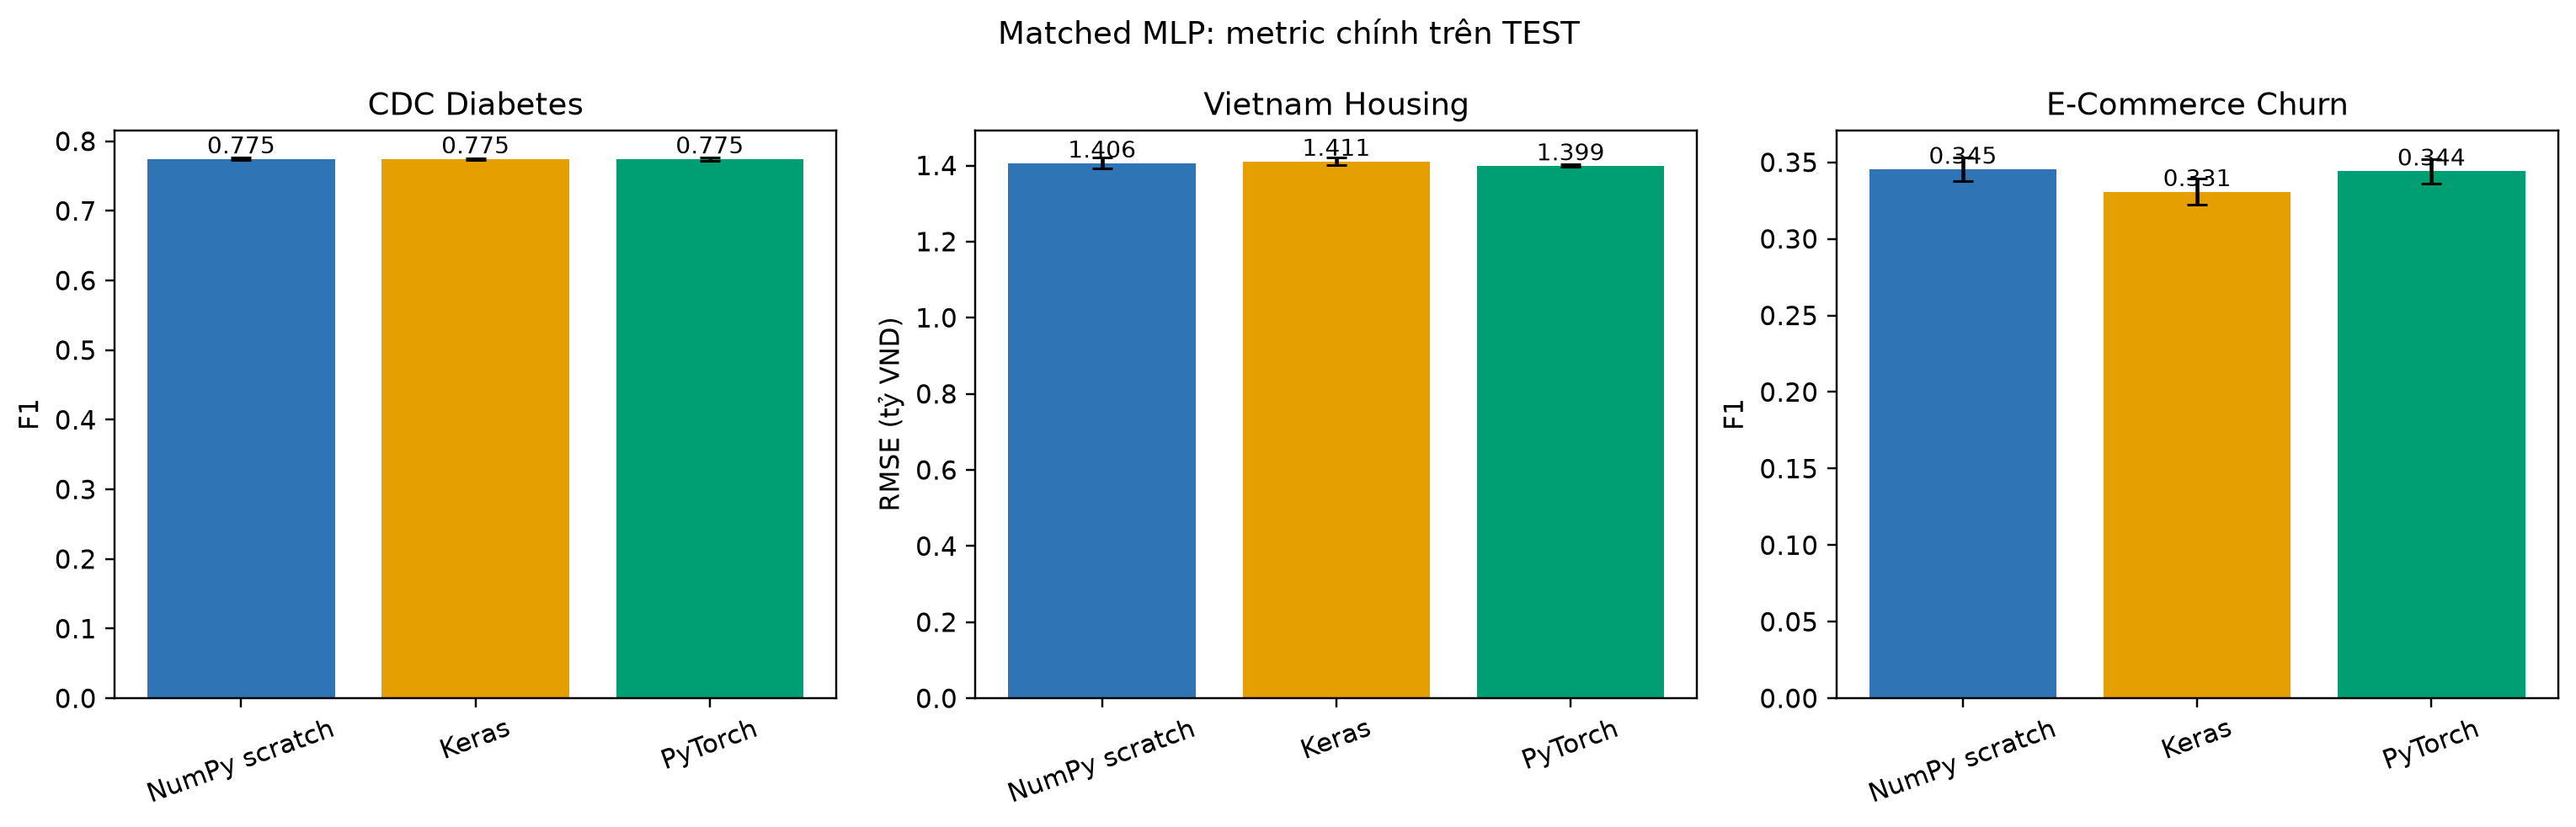

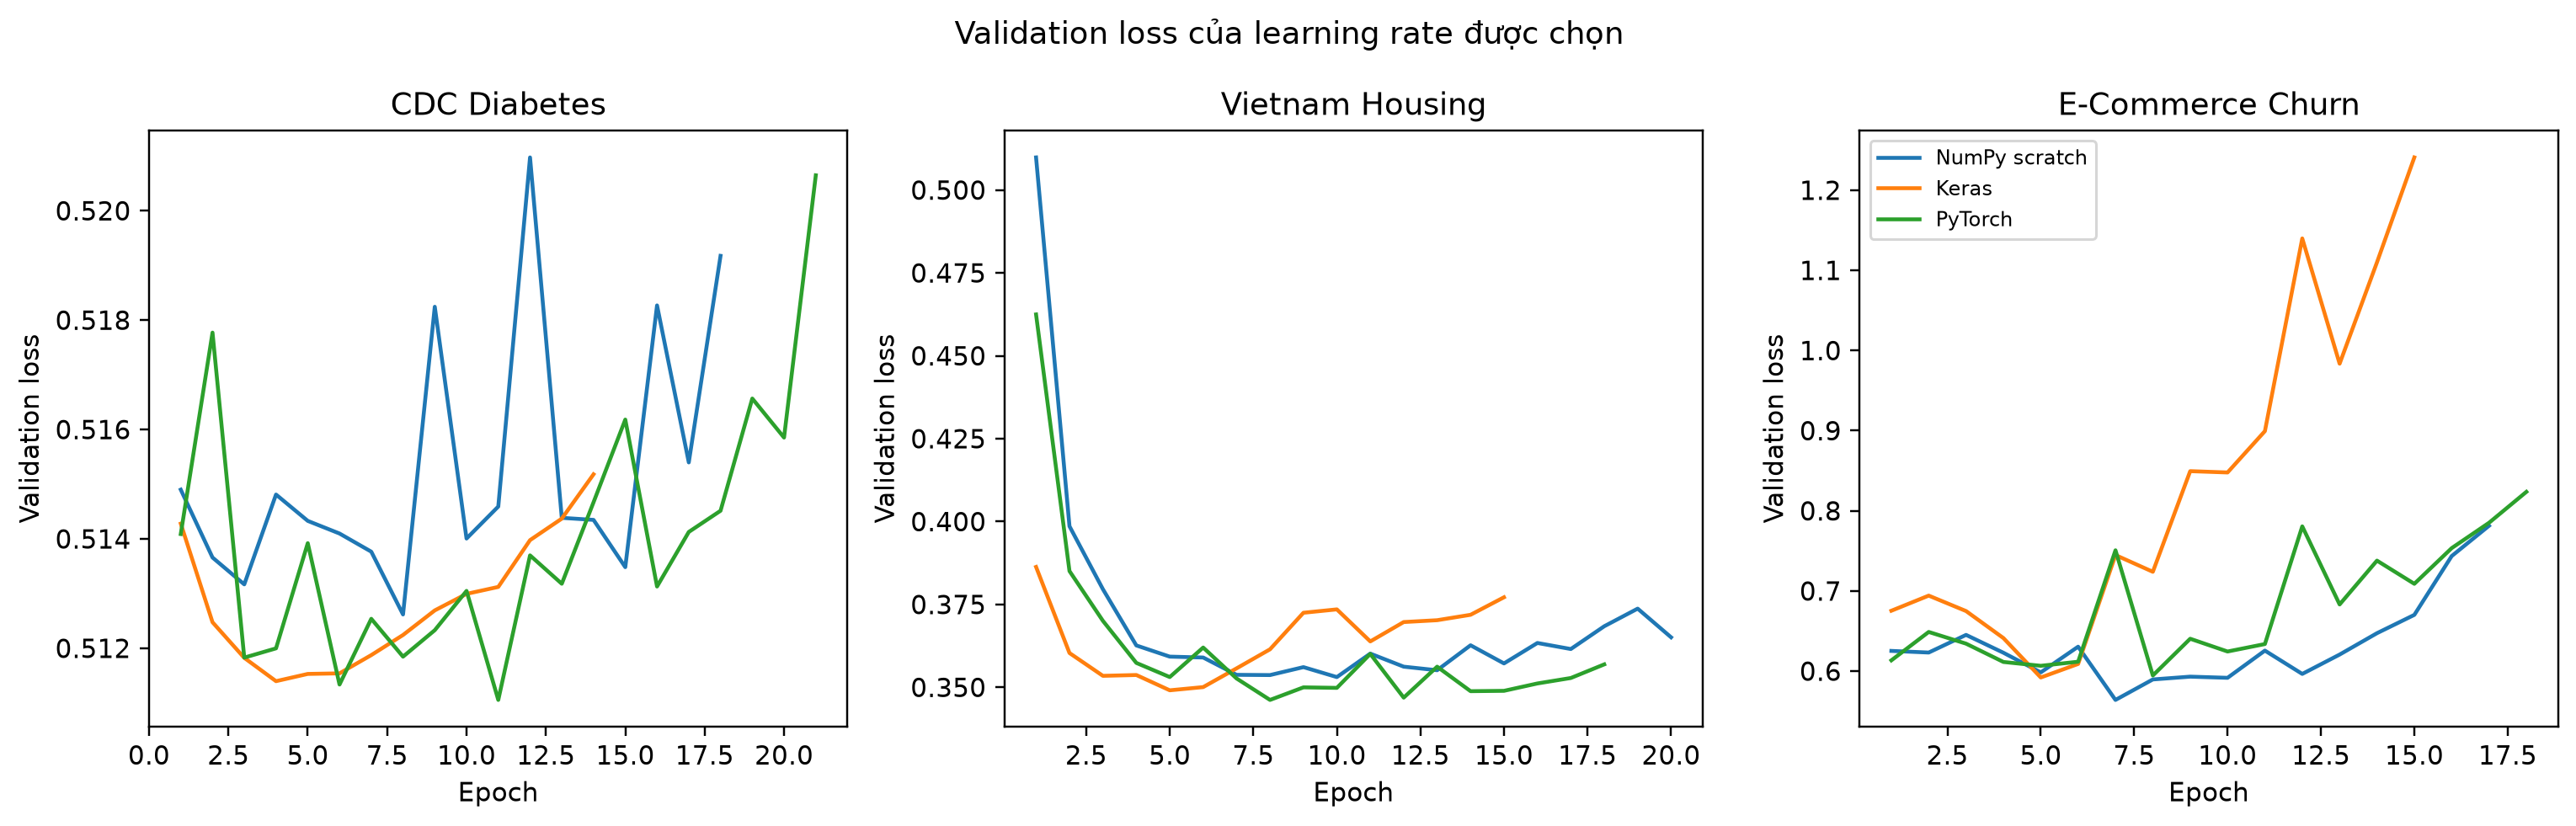

In [4]:
display(Image(filename=str(FIGURES / 'ch2_framework_primary_metrics.png')))
display(Image(filename=str(FIGURES / 'ch2_validation_loss_curves.png')))

## 3. Đối chiếu baseline cổ điển

Baseline cổ điển được giữ nguyên từ ba pipeline nguồn và có SHA-256 của CSV nguồn. Bảng này không giả định topology matched giữa cây/SVM/KNN và MLP; nó chỉ đặt kết quả MLP vào bối cảnh bài toán.

,dataset_id,metric,best_classical_model,best_classical_value,best_matched_framework,best_matched_mean,best_matched_std
0,ch2_diabetes_binary,F1,Random Forest,0.7602,keras,0.7746,0.0014
1,ch2_vietnam_housing,RMSE,Random Forest Regressor,1.4399,pytorch,1.3990,0.0033
2,ch2_ecommerce_behavior,F1,Logistic Regression,0.3562,numpy,0.3454,0.0078


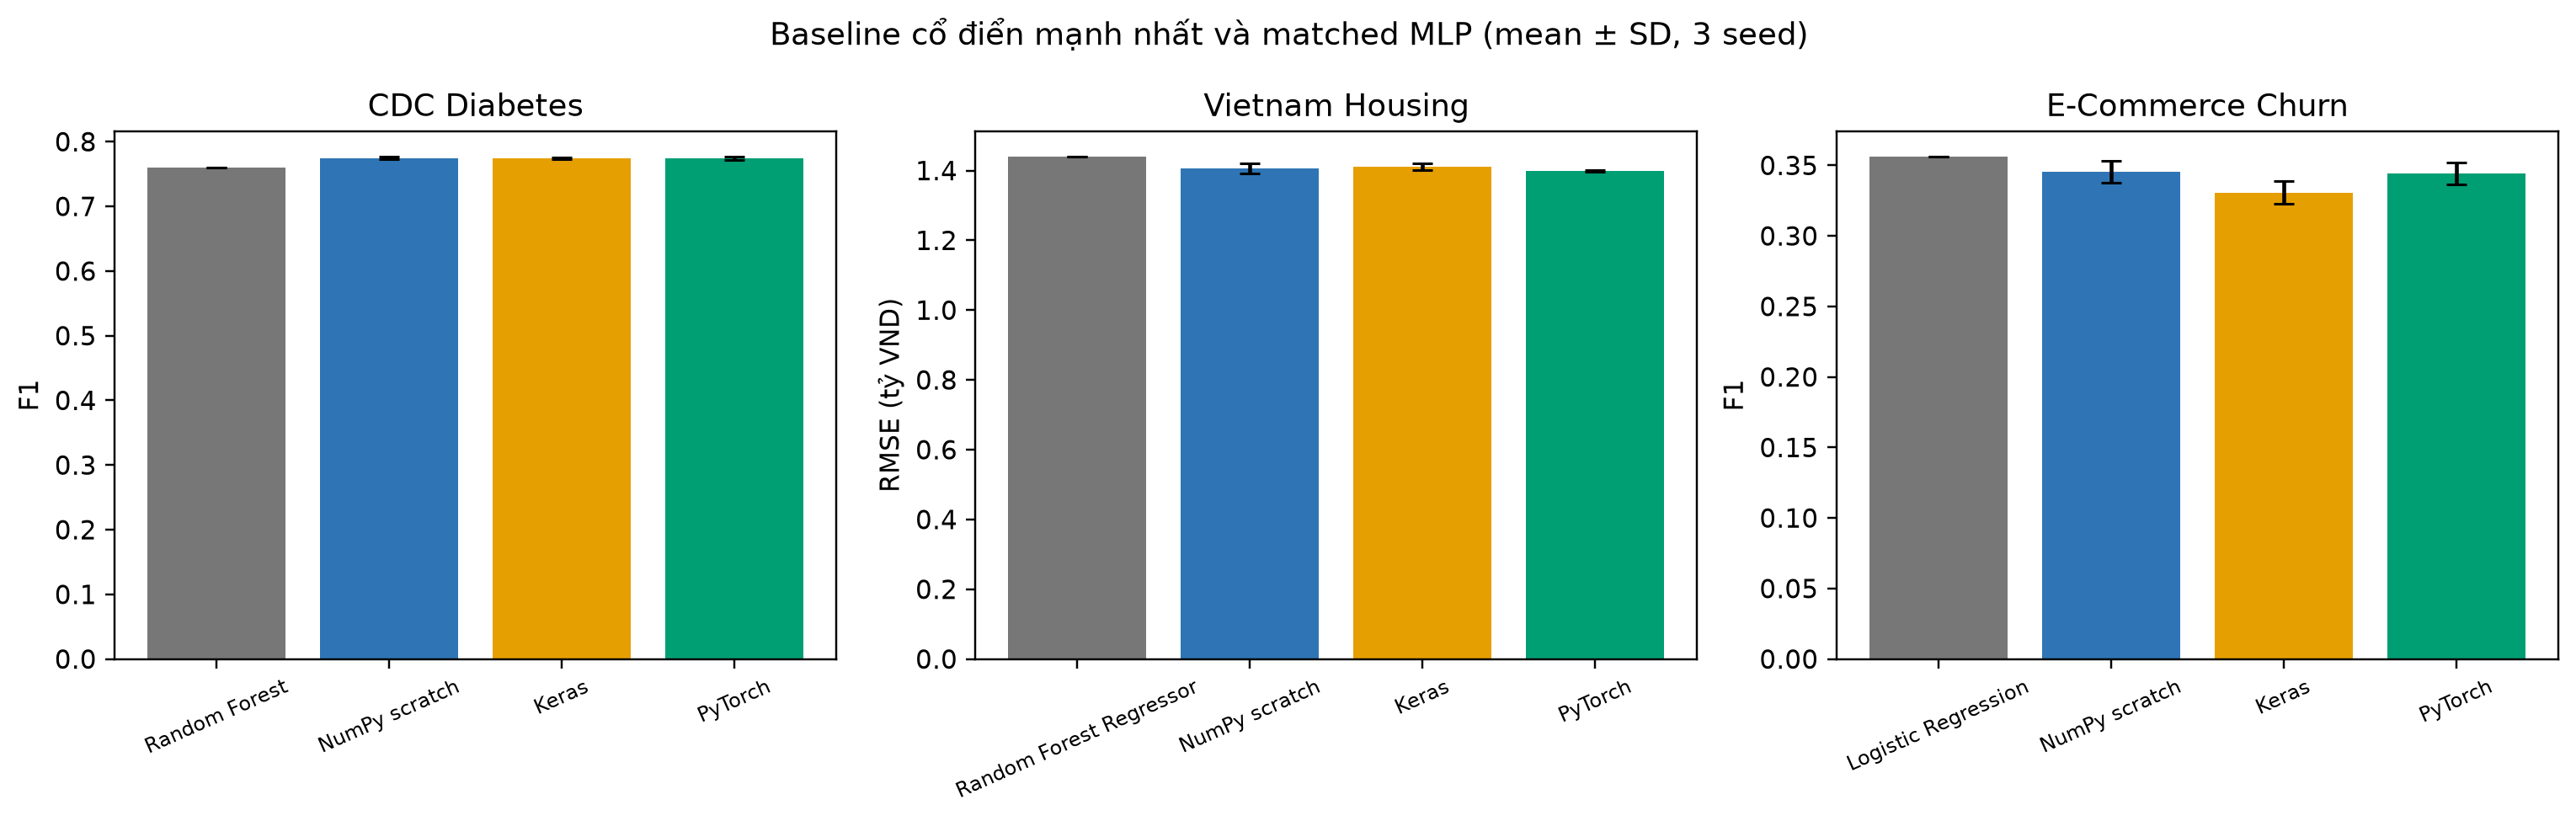

In [5]:
display(best_vs_classical.round(4))
display(Image(filename=str(FIGURES / 'ch2_classical_vs_mlp.png')))

## 4. Lệnh tái lập

Từ workspace root, đặt `CH2_PYTHON` trỏ tới Python đã có NumPy, scikit-learn, TensorFlow/Keras và PyTorch rồi chạy:

```powershell
& $env:CH2_PYTHON -m term_paper.src.common.run_ch2_experiments --workspace (Get-Location).Path
& $env:CH2_PYTHON -m term_paper.src.common.ch2_reporting
```

Không dùng notebook để sửa metric. Nếu prediction thay đổi, metric và hình phải được sinh lại từ script nguồn.